# L6b: Let's Build a Classical Hopfield Network Classifier
In this lab, we'll extend our discussion of Hopfield Networks to build a classical Hopfield Network Classifier. We'll try to memorize and classify images of handwritten digits from the [USPS dataset](https://www.kaggle.com/datasets/bistaumanga/usps-dataset) using both Hebbian and pseudo-inverse learning rules. 

Along the way, we'll analyze how memory correlation structure impacts recall performance and compare the two learning methods under different conditions.

> __Learning Objectives:__
> 
> By the end of this lab, you should be able to:
> * __Construct balanced Hopfield memories:__ Build training and test memory matrices from USPS digit vectors while preventing overlap between sets. Verify class counts before encoding the network.
> * __Measure memory correlation structure:__ Compute correlation matrices for stored digit memories and the lecture uncorrelated image set. Compare their mean off-diagonal magnitudes to quantify interference risk.
> * __Compare Hebbian and pseudo-inverse recall behavior:__ Build both Hopfield model variants and run iterative recovery from noisy or unseen inputs. Evaluate recovery quality using Hamming distance and nearest-memory label checks.

Let's get started!
___

## Setup, Data, and Prerequisites
First, we set up the computational environment by including the `Include.jl` file and loading any needed resources.

> __Environment Setup with Include.jl__
>
> The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, etc. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/).

Let's set up our code environment:

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # include the Include.jl file

In addition to standard Julia libraries, we'll also use [the `VLDataScienceMachineLearningPackage.jl` package](https://github.com/varnerlab/VLDataScienceMachineLearningPackage.jl). Check out [the documentation](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/) for more information on the functions, types, and data used in this material.

### Implementations
The notebook uses local helper functions for Hopfield network operations.

> __Image decoding helper__
>
> * `decode(s; number_of_rows, number_of_columns)`: Converts a flattened state vector $\mathbf{s}$ back to an $n \times n$ image matrix. This local function reshapes the vector, transposes it to match row-major ordering, and replaces $-1$ values with $0$ for grayscale display.

Let's look at the `decode(...)` implementation:

In [2]:
function decode(s::Vector{<: Number}; number_of_rows::Int=28, number_of_columns::Int=28)::Array{<: Number,2}

    # reconstructed image -
    X = reshape(s, number_of_rows, number_of_columns) |> X -> transpose(X) |> Matrix;
    X̂ = replace(X, -1 => 0);
    
    # return -
    return X̂
end;

We will reuse `decode(...)` throughout this notebook to visualize stored, corrupted, and recovered memories. Next, let's formulate the `offdiag_magnitude(...)` function to compute the mean absolute off-diagonal correlation magnitude.

> __Off-diagonal mean helper__
> 
> The `offdiag_magnitude(C)` function takes a correlation matrix `C`, checks that `C` is square with dimension greater than one, and then sets the diagonal terms to zero so self-correlation does not contribute to the statistic. It returns $\frac{1}{n(n-1)}\sum_{i\neq j}|C_{ij}|$, which is the average absolute off-diagonal correlation and gives one scalar measure of overall memory interference.

Let's look at the `offdiag_magnitude(...)` implementation:

In [ ]:
offdiag_magnitude(C::AbstractMatrix) = begin

    nrow, ncol = size(C)
    nrow == ncol || throw(ArgumentError("offdiag_magnitude requires a square matrix."))
    nrow > 1 || throw(ArgumentError("offdiag_magnitude requires n > 1."))

    Cf = Float64.(C)
    C_off = Cf - Diagonal(diag(Cf))  # subtract diagonal
    sum(abs.(C_off)) / (nrow * (nrow - 1))  # divide by n(n-1)
end;

offdiag_magnitude (generic function with 1 method)

### Constants
Before we dive into the data, let's set up some constants that we'll use throughout the notebook. See the comment next to the constant value for more information, e.g., permissible values, units, etc.

In [4]:
number_of_rows = 16; # number of rows in the image
number_of_cols = 16; # number of cols in the image
ϕ = 0.58; # fraction of maximum capacity of the Hopfield Network that we want to use (change this)
number_of_pixels = number_of_rows*number_of_cols; # how many pixels do we have in the image?
KMAX = 0.138*number_of_pixels |> x-> round(x, RoundDown); # maximum capacity of the Hopfield Network (see lecture slides for more details)
number_of_images_to_memorize = Int(ϕ*KMAX |> x-> round(x, RoundDown)); # TODO: number of images that we want to encode (change this)

In [5]:
println("Max number of images that we can encode in the Hopfield Network: ", KMAX)
println("Number of images that we will encode in the Hopfield Network: ", number_of_images_to_memorize)

Max number of images that we can encode in the Hopfield Network: 35.0
Number of images that we will encode in the Hopfield Network: 20


### Data

We load the USPS handwritten digit dataset using [the `MyUSPSHandwrittenDigitImageDataset()` helper function](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/data/#VLDataScienceMachineLearningPackage.MyUSPSHandwrittenDigitImageDataset). The `records` field contains flattened image vectors, and the `labels` field contains digit targets used to build balanced training and test sets.

The original USPS dataset source used in this lab can be found at: [USPS Dataset (Kaggle)](https://www.kaggle.com/datasets/bistaumanga/usps-dataset). This dataset contains 7291 training samples and 2007 test samples of 16x16 pixel grayscale images of handwritten digits (0-9). 

In [6]:
originaldataset = MyUSPSHandwrittenDigitImageDataset(); # load the original dataset records as a NamedTuple (features) labels (targets)

Let's look at a few of these images:

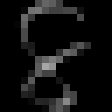

What is the label for this image? 8


In [7]:
let 
    
    # initialize -
    image_index_to_decode = 101;
    s = originaldataset.records[image_index_to_decode];
    label = originaldataset.labels[image_index_to_decode];
    X̂ = decode(s, number_of_rows = number_of_rows, number_of_columns = number_of_cols);

    # print -
    println("What is the label for this image? ", label);

    # show the image -
    Gray.(X̂) |> display
end

Next, let's build a training set of images that we want to memorize in our Hopfield Network. We will use the `number_of_images_to_memorize` variable to control how many images we want to encode in our network. The balance of images can then be used as a test set to evaluate the performance of our network.

> __How are we going to do this?__
>
> We need to load examples of each digit (0-9) into our training set. We can use the `number_digit_array` variable to control which digits we want to include in our training set. For example, if we set `number_digit_array = [0, 1, 2]`, then we will only include images of the digits 0, 1, and 2 in our training set. Alternatively, if we set `number_digit_array = range(0, length=10, step=1) |> collect`, then we will include images of all digits (0-9) in our training set.

In this example, let's include multiple copies of each digit in our training set to increase the likelihood of successful memorization, i.e., the ability to correctly recall stored patterns for test numbers not in our memory (training set). 

We'll save the image feature vectors as a collection stored in the `training_dataset::Array{Int32,2}` variable, and their corresponding labels in the `training_labels::Array{Int32,1}` variable.

In [8]:
training_dataset, training_labels, training_source_indices = let

    # initialize -
    features = originaldataset.records; # image feature vectors stored as rows in this matrix
    labels = originaldataset.labels; # image labels stored as a vector
    number_of_training_images = Int(number_of_images_to_memorize);
    training_dataset = Array{Int32,2}(undef, number_of_pixels, number_of_training_images); # image feature vectors stored as columns in this matrix
    training_labels = Array{Int32,1}(undef, number_of_training_images); # image labels stored as a vector
    training_source_indices = Array{Int32,1}(undef, number_of_training_images); # source indices used to construct training set
    number_digit_array = range(0,length=10,step=1) |> collect; # numbers 0 ... 9

    # build the training dataset -
    # pre-compute and randomize indices for each digit label -
    digit_to_indices = Dict(digit => shuffle!(findall(==(digit), labels)) for digit ∈ number_digit_array);
    digit_to_cursor = Dict(digit => 1 for digit ∈ number_digit_array);

    # cycle 0,1,2,...,9,0,1,2,... until we hit capacity -
    for image_counter ∈ 1:number_of_training_images
        digit = number_digit_array[mod1(image_counter, length(number_digit_array))];
        index_pool = digit_to_indices[digit];
        cursor = digit_to_cursor[digit];

        # if we exhausted this digit pool, reshuffle and reuse -
        if cursor > length(index_pool)
            shuffle!(index_pool);
            cursor = 1;
        end

        image_index = index_pool[cursor];
        digit_to_cursor[digit] = cursor + 1;
        training_dataset[:, image_counter] = Int32.(ifelse.(features[image_index] .>= 0.0, 1, -1));
        training_labels[image_counter] = Int32(labels[image_index]);
        training_source_indices[image_counter] = Int32(image_index);
    end

    # return -
    training_dataset, training_labels, training_source_indices;
end

(Int32[-1 -1 … -1 -1; -1 -1 … -1 -1; … ; -1 -1 … -1 -1; -1 -1 … -1 -1], Int32[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9], Int32[7059, 504, 555, 202, 2113, 2890, 721, 2510, 2309, 6531, 6783, 2486, 1195, 6267, 275, 2271, 2833, 2592, 2614, 3055])

Let's grab a training image and visualize it to make sure everything looks good:

What is the label for this image? 9


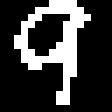

In [9]:
let

    # initialize -
    training_image_to_decode = 10;
    s = training_dataset[:, training_image_to_decode];
    label = training_labels[training_image_to_decode];
    X̂ = decode(s, number_of_rows = number_of_rows, number_of_columns = number_of_cols);

    # print -
    println("What is the label for this image? ", label);

    # show the image -
    Gray.(X̂) |> display
end

__How balanced are we?__ Let's check the labels and see what our training distribution looks like:

In [10]:
let
    
    # check the balance of the training labels -
    number_digit_array = range(0,length=10,step=1) |> collect; # numbers 0 ... 9
    label_counts = Dict(digit => count(==(digit), training_labels) for digit ∈ number_digit_array); # Wow! Super fancy one-liner to count the number of occurrences of each digit label in the training set!
    println("Training label distribution: ", label_counts);
end

Training label distribution: Dict(0 => 2, 4 => 2, 5 => 2, 6 => 2, 2 => 2, 7 => 2, 9 => 2, 8 => 2, 3 => 2, 1 => 2)


Build a test dataset from images that were not used in training. We cycle through digit labels to keep class coverage balanced and assert that test indices do not overlap with training indices.

We will save the held-out image feature vectors in the `test_dataset::Array{Int32,2}` variable, labels in the `test_labels::Array{Int32,1}` variable, and source indices in the `test_source_indices::Array{Int32,1}` variable.

In [11]:
test_dataset, test_labels, test_source_indices = let

    # initialize -
    features = originaldataset.records;
    labels = originaldataset.labels;
    number_digit_array = range(0,length=10,step=1) |> collect; # numbers 0 ... 9
    requested_number_of_test_images = Int(number_of_images_to_memorize); # change this if you want a different test-set size
    used_training_indices = Set(Int.(training_source_indices)); # never reuse training images
    available_digit_indices = Dict(
        digit => shuffle!(filter(idx -> !(idx ∈ used_training_indices), findall(==(digit), labels)))
        for digit ∈ number_digit_array
    );
    digit_to_cursor = Dict(digit => 1 for digit ∈ number_digit_array);

    # cycle 0,1,2,...,9,0,1,2,... until we hit the requested test-set size -
    selected_indices = Int[];
    image_counter = 1;
    while length(selected_indices) < requested_number_of_test_images
        digit = number_digit_array[mod1(image_counter, length(number_digit_array))];
        index_pool = available_digit_indices[digit];
        cursor = digit_to_cursor[digit];

        # stop if we run out of unseen images for a required digit in the cycle -
        if cursor > length(index_pool)
            println("Stopped early at ", length(selected_indices), " test images: no more unseen examples for digit ", digit, ".");
            break;
        end

        image_index = index_pool[cursor];
        push!(selected_indices, image_index);
        digit_to_cursor[digit] = cursor + 1;
        image_counter += 1;
    end

    number_of_test_images = length(selected_indices);
    test_dataset = Array{Int32,2}(undef, number_of_pixels, number_of_test_images);
    test_labels = Array{Int32,1}(undef, number_of_test_images);
    test_source_indices = Array{Int32,1}(undef, number_of_test_images);

    for j ∈ 1:number_of_test_images
        image_index = selected_indices[j];
        test_dataset[:, j] = Int32.(ifelse.(features[image_index] .>= 0.0, 1, -1));
        test_labels[j] = Int32(labels[image_index]);
        test_source_indices[j] = Int32(image_index);
    end

    @assert isempty(intersect(Set(Int.(test_source_indices)), used_training_indices)) "Test set overlaps with training set.";

    test_dataset, test_labels, test_source_indices;
end

(Int32[-1 -1 … -1 -1; -1 -1 … -1 -1; … ; -1 -1 … -1 -1; -1 -1 … -1 -1], Int32[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9], Int32[4258, 5834, 5584, 4671, 3238, 3806, 2023, 5875, 6676, 3435, 3750, 6855, 7244, 1767, 1375, 1353, 3087, 1526, 3356, 7084])

Next, let's compute the correlation matrix for our training dataset. This will give us a sense of how similar the images in our training set are to each other, which can impact the performance of our Hopfield Network. We'll store the correlation matrix in the `C₁::Array{Float64,2}` variable.

In [12]:
C₁ = let

    # Correlation between stored training memories (columns of training_dataset)
    X = Float64.(training_dataset);
    sample_correlation = cor(X, dims=1) |> Matrix;
end

20×20 Matrix{Float64}:
  1.0          -0.103608     0.103917   …  -0.004412    0.0571485
 -0.103608      1.0          0.515479       0.486856    0.00251681
  0.103917      0.515479     1.0            0.393767   -0.0537071
  0.139        -0.0235245    0.0389249      0.0834093  -0.0125433
  0.0424071     0.232149     0.186334       0.295505    0.196096
  0.0860474     0.264304     0.253012   …   0.168957    0.133415
 -0.0038087     0.660097     0.373301       0.399959    0.0833305
  0.0336073     0.197034     0.0721803      0.356647    0.321556
  0.000517693   0.478269     0.47493        0.71108     0.0457523
  0.0632895     0.0884319    0.0267763      0.312042    0.377378
  0.612892     -0.0991125   -0.0101196  …  -0.0886843   0.0455054
 -0.120775      0.721743     0.485798       0.476228   -0.015042
  0.0880575     0.179614     0.318907       0.359704    0.137599
  0.0430168     0.201835     0.172917       0.341501    0.019418
 -0.0625131     0.19696      0.0            0.230267    0.2

In addition to looking at the correlation for the training images, let's compare that set with the uncorrelated images we used in the lecture example. We'll save the lecture correlation matrix in the `C₀::Array{Float64,2}` variable.

In [13]:
C₀ = let 

    # initialize -
    training_image_array =  MyUncorreleatedBlackAndWhiteImageDataset(); # load the uncorrelated image dataset records as a NamedTuple (features) labels (targets)
    lecture_number_of_rows, lecture_number_of_cols = size(training_image_array[:,:,1]);
    number_of_pixels = lecture_number_of_rows*lecture_number_of_cols;
    number_of_training_examples = size(training_image_array, 3);
    X = Array{Float32,2}(undef, number_of_pixels, number_of_training_examples); # image feature vectors stored as columns in this matrix

    for t ∈ 1:number_of_training_examples

        Y = training_image_array[:,:,t]; # grab the t-th image
        D = reshape(transpose(Y) |> Matrix, number_of_pixels) |> vec |> x -> convert.(Float32,x); # flatten and convert to Float32
        X[:,t] = D; # store as a column in the training dataset
    end

    sample_correlation = cor(X, dims=1) |> Matrix;
end

100×100 Matrix{Float32}:
  1.0          0.0140511   -0.0173859   …  -0.0257638    -0.0224321
  0.0140511    1.0          0.0283235       0.0418697    -0.0143399
 -0.0173859    0.0283235    1.0            -0.00445289    0.0155562
  0.0193108    0.00970971   0.0130087       0.0166653     0.0435557
  0.0363056   -0.0190877    0.0820825      -0.043262      0.00924511
 -0.0131554    0.039246    -0.0377056   …   0.00955303    0.037267
  0.00537183   0.00405958   0.0506112      -0.0224377    -0.00530526
 -0.0292397   -0.0554732    0.0380371      -0.0622979     0.0436745
 -0.0407769   -0.0203934   -0.0280702      -0.0228215     0.0857937
 -0.0432271    0.0179758   -0.0357543       0.000227481  -0.0158413
  ⋮                                     ⋱                
  0.0410358    0.0409739   -0.0381927      -0.0433224     0.0612435
 -0.0147917   -0.0342685    0.0463845      -0.00735609    0.0326363
 -0.0481672    0.0324768   -0.00832931     -0.0449542    -0.0580452
 -0.0539451   -0.0131098    0.05

__Question:__ Compare the correlation structure of `C₁` (digit memories) and `C₀` (lecture uncorrelated memories). Which matrix has the larger off-diagonal magnitude, and what does that imply about expected interference and recall reliability in a classical Hopfield network? 

If the `C₁` magnitude is much larger, would you expect the practical memory limit to be closer to or lower than the $K_{max}=0.138N$ rule-of-thumb, and why?
___

## Task 1: Classical Hopfield Network Classifier with Hebbian Learning
In this task, we'll implement a classical Hopfield Network Classifier using Hebbian learning, i.e., we'll use the data to compute the weights of the Hopfield Network and then use the network to classify new images.

### Correlation Check
Before we get started, let's do a check. We know that correlation between the training images, i.e., the stored memories can lead to interference in the network's ability to recall the correct image. The $K_{max} = 0.138 N$ rule of thumb gives us an estimate of how many __uncorrelated images__ we can memorize in our network before we start to see significant interference. 

__Comparison__: Let's compare the off-diagonal magnitude of the correlation matrix for our training set to the off-diagonal magnitude of the correlation matrix for the uncorrelated images that we used in lecture. 

> __What is off-diagonal magnitude?__
>
> We'll use the mean absolute value of the off-diagonal elements of the correlation matrix as a measure of how correlated the training images are with each other. For a correlation matrix $\mathbf{C}$, we compute
> $$m(\mathbf{C}) = \frac{1}{n(n-1)} \sum_{i=1}^{n} \sum_{j=1, j \neq i}^{n} |C_{ij}| = \frac{1}{n(n-1)} \left( \sum_{i=1}^{n} \sum_{j=1}^{n} |C_{ij}| - \sum_{i=1}^{n} |C_{ii}| \right).$$
> Here, $n$ is the matrix dimension (number of stored images). Larger values of $m(\mathbf{C})$ indicate stronger average pairwise correlation and typically more retrieval interference in a classical Hopfield network.

What do you notice? What does this mean for the performance of our network?

In [14]:
lab_mag   = offdiag_magnitude(C₁)
lecture_mag = offdiag_magnitude(C₀)
@show lab_mag lecture_mag lab_mag/lecture_mag

lab_mag = 0.18296164794201206
lecture_mag = 0.028518959208645587
lab_mag / lecture_mag = 6.415439168149826


6.415439168149826


Now that we have the training images let's encode the model. We'll compute the weights and the bias term and store them [in an instance of the `MyClassicalHopfieldNetworkModel` type](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/hopfield/#VLDataScienceMachineLearningPackage.MyClassicalHopfieldNetworkModel). The weights are stored in the `W` field, and the bias term is stored in the `b` field. 

> __How do we build this model?__
> 
> We build the model (and estimate the weight matrix and bias vector) using [the `build(...)` method](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/factory/). This method takes the type of thing we want to construct, namely [a `MyClassicalHopfieldNetworkModel` instance](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/hopfield/#VLDataScienceMachineLearningPackage.MyClassicalHopfieldNetworkModel), and the memories we want to encode. The (vectorized) memories are stored in the columns of an array. The [`build(...)` method](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/factory/) returns a model instance with the `W` and `b` fields populated.

Let's store the encoded model in the `model::MyClassicalHopfieldNetworkModel` variable.

In [15]:
model = build(MyClassicalHopfieldNetworkModel, (
    memories = training_dataset, # load the training images as the memories to encode in the Hopfield Network
));

Now, let us give the model a memory and see if it can recover it. We will look at examples of various difficulties, e.g., a clean memory, a noisy memory, and a completely random input of a digit in the test set (never seen by the model before). 

> __How do we recover a memory in this notebook?__ 
> 
> We use [the `recover(...)` method](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/hopfield/#VLDataScienceMachineLearningPackage.recover) with the trained model, an initial state vector, and stopping controls (`maxiterations` and `patience`). This method returns a dictionary of recovered states (`frames`) and an energy history dictionary (`energydictionary`) that we can scan to find the minimum-energy recovered state.

Let us start with a clean memory, and then get progressively more difficult. This code cell returns `(f₁::AbstractDict, e₁::AbstractDict, s::Vector{Int32}, s₁::Vector{Int32}, label::Int32)`, where `f₁` stores recovered states by iteration index and `e₁` stores energy values by iteration index.

In [ ]:
(f₁,e₁, s, s₁, label) = let

    # initialize -
    memory_to_recall = rand(1:size(training_dataset, 2)); # change this to select a different memory to recall from the training set
    θ = 0.90; # fraction of pixels that we want to keep correct during the recall process (change this)

    #=
    # Case 1: Give the model a clean memory to recall -
    label = training_labels[memory_to_recall];
    # true_image_energy = -Inf32; # we can set this to -Inf if we want the recall process to be controlled by maxiterations/patience rather than early-stopping on this threshold
    true_image_energy = model.energy[memory_to_recall]; # Give the true energy if we want to use early-stopping based on this threshold
    s₁ = training_dataset[:, memory_to_recall]; # true memory we want to recall
    s = training_dataset[:, memory_to_recall]; # initial state for the recall process (in this case, we give the model the clean memory as the initial state)
    =#

    
    # Case 2: Give the model a noisy memory to recall -
    label = training_labels[memory_to_recall];
    # true_image_energy = model.energy[memory_to_recall] |> Float32; # we can use a fraction of the true energy if we want to make it easier for the recall process to succeed (i.e. easier early-stopping based on this threshold)
    true_image_energy = -Inf32; # we can set this to -Inf if we want the recall process to be controlled by maxiterations/patience rather than early-stopping on this threshold
    s₁ = training_dataset[:, memory_to_recall]; # true memory we want to recall
    s = copy(s₁); # initial state for the recall process

    # cut 1 - θ fraction of the pixels, replace with - 1
    number_of_pixels_to_corrupt = round(Int, (1 - θ)*number_of_pixels);
    start =(number_of_pixels - number_of_pixels_to_corrupt) + 1;
    for i ∈ start:number_of_pixels
        s[i] = -1;
    end

    #=
    # Case 3: Pull a random image from the test set (never seen by the model before) and give it to the model to recall -
    random_test_image_index = rand(1:size(test_dataset, 2));
    label = test_labels[random_test_image_index];
    s₁ = test_dataset[:, random_test_image_index]; # held-out test image (not used during training)
    s = copy(s₁); # initial state for the recall process
    true_image_energy = -Inf32; # unknown for test images; use -Inf so recall is controlled by maxiterations/patience, not early-stop on this threshold
    println("Min Hamming (random test input vs training set) = ", minimum(hamming(s₁, training_dataset[:, i]) for i ∈ 1:size(training_dataset, 2)))
    =#

    # run the recall process -
    frames, energydictionary = recover(model, s, true_image_energy, maxiterations=1000*number_of_pixels, 
        patience = number_of_pixels);

    # get the recovered image -
    ks = collect(keys(energydictionary))
    best_key = argmin(k -> energydictionary[k], ks)
    best_state = frames[best_key]

    # print some data for this recall process -
    println("Hamming (best recovered memory vs true memory) = ", hamming(best_state, s₁))
    println("Hamming (best recovered memory vs initial memory) = ", hamming(best_state, s))

    # return the frames -
    (frames, energydictionary,s, s₁, label)
end;

┌ Info: Convergence detected: no state changes over the last 256 iterations and all neurons visited since last change. Stopping.
└ @ VLDataScienceMachineLearningPackage /Users/jeffreyvarner/.julia/packages/VLDataScienceMachineLearningPackage/d50ED/src/Hopfield.jl:147


Hamming (best recovered memory vs true memory) = 89
Hamming (best recovered memory vs initial memory) = 89


Which image does the model recover? The code block below displays the true image (top), the corrupted initial image (middle), and the recovered image (bottom).

> __Check:__ 
> 
> To evaluate the quality of the recovered image, we can compute the Hamming distance between the recovered state and the true image. The Hamming distance quantifies the number of differing pixels, providing a measure of retrieval accuracy. A lower Hamming distance indicates a closer match to the original image. If the Hamming distance is zero, it means the recovered image exactly matches the true image.
> 
> We check if the Hamming distance between the recovered image and the true image is less than the Hamming distance between the corrupted image and the true image. If it is, no error is thrown; otherwise, an error is raised indicating that the recovery was unsuccessful.

So what do we get?

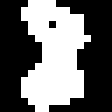

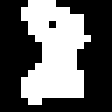

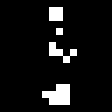

The label for the image we tried to recall was: 8


In [18]:
let

    # initialize -
    frames = f₁;
    energydictionary = e₁;
    
    # get the initial image -
    initial_image = decode(s, number_of_rows = number_of_rows, number_of_columns = number_of_cols);
    true_image = decode(s₁, number_of_rows = number_of_rows, number_of_columns = number_of_cols);
    
    # Get the best recovered image -
    ks = collect(keys(energydictionary))
    best_key = argmin(k -> energydictionary[k], ks)
    best_state = frames[best_key]
    recovered_image = decode(best_state, number_of_rows = number_of_rows, number_of_columns = number_of_cols);

    # what was the label for the image we tried to recall? -
    println("The label for the image we tried to recall was: ", label);

    # Show the images -
    Gray.(true_image) |> display;
    Gray.(initial_image) |> display;
    Gray.(recovered_image) |> display;
end;

__What about the label?__ We can also check the label of the recovered image to see if it matches the true label. The label of the recovered image is determined by finding the closest memory in the model's memories to the recovered state vector. 

We compute the Hamming distance between the recovered state vector and each of the memories in the model, and then find the memory with the smallest Hamming distance. The label of that memory is then assigned as the predicted label for the recovered image.

In [19]:
let

    # initialize -
    frames = f₁;
    energydictionary = e₁;

    # get the recovered memory
    best_key = collect(keys(energydictionary)) |> ks -> argmin(k -> energydictionary[k], ks)
    best_state = frames[best_key]

    #  ok, so need to find the closest training image to this recovered memory -
    hamming_distances = [hamming(best_state, training_dataset[:, i]) for i ∈ 1:size(training_dataset, 2)];
    closest_training_image_index = argmin(hamming_distances);
    closest_training_image_label = training_labels[closest_training_image_index];

    # what is the label of the closest training image to the recovered memory?
    println("The label of the closest training image to the recovered memory is: ", closest_training_image_label);
end

The label of the closest training image to the recovered memory is: 6


__Question:__ In Task 1 we tested three input cases (clean training memory, corrupted training memory, and unseen test image). For each case, did the network recover the correct pattern and label, and where did failure occur?

How does any observed failure connect to the correlation levels measured in `C₁`, and what role might spurious attractors play in that behavior?
___

## Task 2: Classical Hopfield Network Classifier with Pseudo-Inverse Learning
In this task, we will implement a classical Hopfield Network Classifier using Pseudo-Inverse learning, i.e., we will use the data to compute the weights of the Hopfield Network using the pseudo-inverse method and then use the network to classify new images.

There is an alternative learning rule for Hopfield Networks called the pseudo-inverse learning rule. This learning rule can be used to compute the weights of the Hopfield Network in a way that minimizes the error between the stored memories and the recalled memories. In this notebook, we compute:
$$
\begin{align*}
\mathbf{W} &= \mathbf{X} \mathbf{X}^{+} - \mathrm{diag}\!\left(\mathbf{X} \mathbf{X}^{+}\right) \\
\mathbf{b} &= \mathbf{0}
\end{align*}
$$
where $\mathbf{X}$ is the memory matrix (each memory is a column), $\mathbf{X}^{+}$ is the Moore-Penrose pseudo-inverse computed with [the `pinv` method](https://docs.julialang.org/en/v1/stdlib/LinearAlgebra/#LinearAlgebra.pinv), and $\mathrm{diag}(\cdot)$ builds a diagonal matrix from the diagonal entries of its argument. This exactly matches the implementation where we zero the diagonal of $\mathbf{X}\mathbf{X}^{+}$ before assigning `W`.

Let us check this out. First, let us compute the new weights and bias term using the pseudo-inverse learning rule and store them in the `updated_model::MyClassicalHopfieldNetworkModel` variable.

In [20]:
updated_model = let

    # initialize -
    local_model = deepcopy(model); # make a copy of the original model so we can update it without affecting the original

    # compute the pseudo-inverse weights and bias term -
    X = local_model.memories;
    tmp = X * pinv(X);
    D = Diagonal(diag(tmp));
    W = tmp - D; # compute the pseudo-inverse weights using the Moore-Penrose pseudo-inverse

    # update the model's weights and bias term -
    local_model.W = W;
    local_model.b = zeros(size(model.b)); # set the bias term to zero  

    local_model;
end

MyClassicalHopfieldNetworkModel([0.0 0.012776605813728538 … 0.012776605813728591 0.012776605813728591; 0.012776605813728588 0.0 … 0.012776605813728591 0.012776605813728591; … ; 0.012776605813728588 0.012776605813728538 … 0.0 0.012776605813728591; 0.012776605813728588 0.012776605813728538 … 0.012776605813728591 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], Int32[-1 -1 … -1 -1; -1 -1 … -1 -1; … ; -1 -1 … -1 -1; -1 -1 … -1 -1], Dict{Int64, Float32}(5 => -513.41406, 16 => -509.53906, 20 => -343.1328, 12 => -721.4453, 8 => -565.02344, 17 => -571.1953, 1 => -263.39844, 19 => -408.9297, 6 => -418.8047, 11 => -346.8672…))

Do the new weights perform better than the weights computed using the Hebbian learning rule? Let us check by recalling the same memories as before and comparing the results.

This code cell returns `(f₂::AbstractDict, e₂::AbstractDict, s_initial_task_2::Vector{Int32}, s₂::Vector{Int32}, l₂::Int32)` for the pseudo-inverse recall run.

In [36]:
(f₂,e₂, s_initial_task_2, s₂,l₂) = let

    #=
    # Case 2: Give the model a noisy memory to recall -
    memory_to_recall = rand(1:size(training_dataset, 2)); # change this to select a different memory to recall from the training set
    θ = 0.60; # fraction of pixels that we want to keep correct during the recall process (change this)

    l₂ = training_labels[memory_to_recall];
    # true_image_energy = model.energy[memory_to_recall] |> Float32; # we can use a fraction of the true energy if we want to make it easier for the recall process to succeed (i.e. easier early-stopping based on this threshold)
    true_image_energy = -Inf32; # we can set this to -Inf if we want the recall process to be controlled by maxiterations/patience rather than early-stopping on this threshold
    s_true = training_dataset[:, memory_to_recall]; # true memory we want to recall
    s_initial_task_2 = copy(s_true); # initial state for the recall process

    # cut 1 - θ fraction of the pixels, replace with - 1
    number_of_pixels_to_corrupt = round(Int, (1 - θ)*number_of_pixels);
    start =(number_of_pixels - number_of_pixels_to_corrupt) + 1;
    for i ∈ start:number_of_pixels
        s_initial_task_2[i] = -1;
    end
    =#


    # Case 3: Pull a random image from the test set (never seen by the model before) and give it to the model to recall -
    random_test_image_index = rand(1:size(test_dataset, 2));
    l₂ = test_labels[random_test_image_index];
    s_true = test_dataset[:, random_test_image_index]; # held-out test image (not used during training)
    s_initial_task_2 = copy(s_true); # initial state for the recall process
    true_image_energy = -Inf32; # unknown for test images; use -Inf so recall is controlled by maxiterations/patience, not early-stop on this threshold
    println("Min Hamming (random test input vs training set) = ", minimum(hamming(s_initial_task_2, training_dataset[:, i]) for i ∈ 1:size(training_dataset, 2)))

    # run the recall process -
    frames, energydictionary = recover(updated_model, s_initial_task_2, true_image_energy, maxiterations=1000*number_of_pixels, 
        patience = number_of_pixels);

    # get the recovered image -
    ks = collect(keys(energydictionary))
    best_key = argmin(k -> energydictionary[k], ks)
    best_state = frames[best_key]

    # print some data for this recall process -
    println("Hamming (best recovered memory vs true memory) = ", hamming(best_state, s_true))
    println("Hamming (best recovered memory vs initial memory) = ", hamming(best_state, s_initial_task_2))

    # return the frames -
    (frames, energydictionary,s_initial_task_2, s_true, l₂)
end;

Min Hamming (random test input vs training set) = 50


┌ Info: Recovered exact stored memory index = 8. Stopping.
└ @ VLDataScienceMachineLearningPackage /Users/jeffreyvarner/.julia/packages/VLDataScienceMachineLearningPackage/d50ED/src/Hopfield.jl:127


Hamming (best recovered memory vs true memory) = 50
Hamming (best recovered memory vs initial memory) = 50


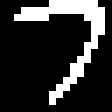

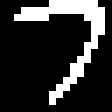

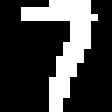

The label for the image we tried to recall was: 7


In [37]:
let

    # initialize -
    frames = f₂;
    energydictionary = e₂;
    
    # get the initial image -
    initial_image = decode(s_initial_task_2, number_of_rows = number_of_rows, number_of_columns = number_of_cols);
    true_image = decode(s₂, number_of_rows = number_of_rows, number_of_columns = number_of_cols);
    
    # Get the best recovered image -
    ks = collect(keys(energydictionary))
    best_key = argmin(k -> energydictionary[k], ks)
    best_state = frames[best_key]
    recovered_image = decode(best_state, number_of_rows = number_of_rows, number_of_columns = number_of_cols);

    # what was the label for the image we tried to recall? -
    println("The label for the image we tried to recall was: ", l₂);

    # Show the images -
    Gray.(true_image) |> display;
    Gray.(initial_image) |> display;
    Gray.(recovered_image) |> display;
end;

__What about the label?__ We can also check the label of the recovered image (using the new weights) to see if it matches the true label. The label of the recovered image is determined by finding the closest memory in the model's memories to the recovered state vector. 

We compute the Hamming distance between the recovered state vector and each of the memories in the model, and then find the memory with the smallest Hamming distance. The label of that memory is then assigned as the predicted label for the recovered image.

In [38]:
let

    # initialize -
    frames = f₂;
    energydictionary = e₂;

    # get the recovered memory
    best_key = collect(keys(energydictionary)) |> ks -> argmin(k -> energydictionary[k], ks)
    best_state = frames[best_key]

    #  ok, so need to find the closest training image to this recovered memory -
    hamming_distances = [hamming(best_state, training_dataset[:, i]) for i ∈ 1:size(training_dataset, 2)];
    closest_training_image_index = argmin(hamming_distances);
    closest_training_image_label = training_labels[closest_training_image_index];

    # what is the label of the closest training image to the recovered memory?
    println("The label of the closest training image to the recovered memory is: ", closest_training_image_label);
end

The label of the closest training image to the recovered memory is: 7


__Question:__ Using the same initial samples and recall settings, does the pseudo-inverse learning improve over Hebbian learning? Compare Hamming distance to the true memory and label recovery for both models.

If performance differs across samples, what pattern do you observe, and why might `pinv`-based weights help more when memories are correlated?
___

## Summary
This notebook builds a classical Hopfield classifier for handwritten digits and shows how memory correlation affects retrieval behavior.

> __Key Takeaways:__
> 
> * **Balanced memory construction matters:** The training and test sets are assembled with digit coverage while preventing overlap between encoded and held-out images. This setup makes recall experiments easier to interpret because leakage is avoided by construction.
> * **Correlation magnitude provides a compact interference signal:** The mean absolute off-diagonal correlation summarizes how strongly stored memories interact. Comparing this statistic between digit memories and uncorrelated lecture images gives a direct interference comparison.
> * **Learning rule choice changes recovery outcomes:** Hebbian and pseudo-inverse weights can produce different recovered states from the same initial condition. Hamming distance and nearest-memory label checks provide a concrete way to compare those outcomes.

Together, these checks give a reproducible workflow for diagnosing and improving Hopfield memory retrieval.
___